# Distribution Sanity Checks — v3

Refactor of v2 addressing four design issues raised after running v2 on the
real 68-dict corpus:

1. **Proportional tier severity.** v2 used "≥2 violations = broken"
   uniformly. This penalized Morph (only 2 rules) and let Parcor through
   (4 rules, so 50% violations only). v3 uses a proportional rule:
   ≥60% of applicable rules violated = broken. Concretely:
   - Billex (3 rules): broken needs ≥2/3 = 67% (unchanged in practice)
   - Morph (2 rules): broken needs 2/2 = 100%
   - Parcor (4 rules): broken needs ≥3/4 = 75%

2. **Separate fix-evaluation narrative.** v2 mixed fix-impact reporting
   with tier classification. v3 separates them: §8 evaluates each fix
   against its targeted rule independently, §9 computes structural tiers
   independently. The two analyses sit side-by-side and don't conflate.

3. **Per-resource tier reporting.** v2 reported only overall tiers. v3
   adds explicit per-resource tier counts, per-resource transitions, and
   a "broken on N resources" breakdown. Overall tiers are still reported
   (§9.4) but the per-resource view is primary.

4. **Three-tier verdicts on fix scripts.** Each fix script targeting a
   rule gets a simple verdict: succeeded (any improvement), no-effect
   (zero change), or regressed (count went up).

## Outputs (in `../evaluation/sanity_v3/`)

Same file roster as v2 but reorganized:

- `_per_dict_metrics.csv` — wide format with per-resource and overall tiers
- `_quality_tiers.csv` — per-dict tier summary (pre + post for all 4 levels)
- `_per_resource_transitions.csv` — tier transition counts per resource
- `_fix_evaluation_report.csv` — per-targeted-rule pre/post and verdict
- `_fix_evaluation_per_dict.csv` — per-dict drill-down for each fix
- `_catastrophic_failures.csv` — extraction-stage failures (kept from v2)
- `_aggregate_stats.csv` — single-row corpus summary
- `_source_profiles.csv` — source feature detection results

Plots:
- `_tier_breakdown.png` — 4-panel: overall pre, overall post, per-resource
  pre, per-resource post
- `_tier_transitions.png` — 3-panel transition matrices, one per resource
- `_fix_evaluation.png` — bar chart of targeted rule violation counts

Note: this v3 leaves v2 intact. Output goes to `sanity_v3/` so v2 outputs
remain accessible for comparison.

## 1. Imports & paths

In [22]:
import re
import ast
from pathlib import Path
from collections import Counter
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":         Path("../Ekstraksi/6. Pemecahan Definisi Lema"),
    "billex":       Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":        Path("../Ekstraksi/10. Morphology"),
    "parcor":       Path("../Ekstraksi/11. Parallel Corpus"),
    "billex_fixed": Path("../Ekstraksi/9. Bilingual Lexicon - Fixed"),
    "morph_fixed":  Path("../Ekstraksi/10. Morphology - Fixed"),
    "parcor_fixed": Path("../Ekstraksi/11. Parallel Corpus - Fixed"),
}

CALIBRATION = Path("../csvAnalysis/distribution_exploration/_my_thresholds.csv")
DST_DIR = Path("../csvAnalysis/sanity_v3")
DST_DIR.mkdir(parents=True, exist_ok=True)

# REFERENCE_GOOD_DICTS = ["10", "35", "68", "91"]

# v3 design parameter — broken if proportion of applicable rules violated >= this
BROKEN_PROPORTION_THRESHOLD = 0.60

for name, d in DIRS.items():
    print(f"  {name:<14}  exists={d.exists()}  {d}")
print(f"\n  calibration    exists={CALIBRATION.exists()}  {CALIBRATION}")
print(f"\nWriting to: {DST_DIR.resolve()}")

assert CALIBRATION.exists(), (
    f"Run Threshold Calibration.ipynb first to produce {CALIBRATION}"
)

  prep            exists=True  ..\Ekstraksi\6. Pemecahan Definisi Lema
  billex          exists=True  ..\Ekstraksi\9. Bilingual Lexicon
  morph           exists=True  ..\Ekstraksi\10. Morphology
  parcor          exists=True  ..\Ekstraksi\11. Parallel Corpus
  billex_fixed    exists=True  ..\Ekstraksi\9. Bilingual Lexicon - Fixed
  morph_fixed     exists=True  ..\Ekstraksi\10. Morphology - Fixed
  parcor_fixed    exists=True  ..\Ekstraksi\11. Parallel Corpus - Fixed

  calibration    exists=True  ..\csvAnalysis\distribution_exploration\_my_thresholds.csv

Writing to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\sanity_v3


## 2. Load calibrated thresholds

Same as v2 — uses `_threshold_justifications.csv` from threshold calibration
notebook. Rules are grouped per resource for the proportional tier rule.

In [23]:
thresholds_df = pd.read_csv(CALIBRATION)
print(f"Loaded {len(thresholds_df)} calibrated thresholds")

RESOURCE_RULES = {
    "billex": [],
    "morph":  [],
    "parcor": [],
}
for _, row in thresholds_df.iterrows():
    rule = row["rule_name"]
    for resource in RESOURCE_RULES:
        if rule.startswith(resource + "_"):
            RESOURCE_RULES[resource].append({
                "rule": rule,
                "metric": row["metric_column"],
                "threshold": row["chosen_threshold"],
                "direction": row["direction"],
            })
            break

for r, rules in RESOURCE_RULES.items():
    rule_names = [info["rule"] for info in rules]
    n = len(rules)
    threshold_pct = int(BROKEN_PROPORTION_THRESHOLD * 100)
    min_for_broken = int(np.ceil(n * BROKEN_PROPORTION_THRESHOLD))
    print(f"  {r}: {n} rules → broken if ≥{min_for_broken}/{n} violated (≥{threshold_pct}%)")
    for rn in rule_names:
        print(f"    - {rn}")

Loaded 9 calibrated thresholds
  billex: 3 rules → broken if ≥2/3 violated (≥60%)
    - billex_high_multiword_ind
    - billex_high_null_rate
    - billex_low_retention
  morph: 2 rules → broken if ≥2/2 violated (≥60%)
    - morph_low_tag_coverage
    - morph_too_few_rows
  parcor: 4 rules → broken if ≥3/4 violated (≥60%)
    - parcor_high_placeholders
    - parcor_too_few_rows
    - parcor_high_null_rate
    - parcor_high_short_rows


## 3. Fix-to-rule mapping

The fix evaluation in §8 uses this mapping to know which rule each fix
script targets. Diagnostic only — does not gate tier classification.

In [24]:
FIX_TO_RULES = {
    "fix_billex_headword_batch":    ["billex_high_multiword_ind"],
    "fix_morphology_split_batch":   ["morph_low_tag_coverage"],
    "fix_parcor_batch":             ["parcor_high_placeholders"],
}
RULE_TO_FIX = {rule: fix for fix, rules in FIX_TO_RULES.items() for rule in rules}

print("Fix → Rules mapping:")
for fix, rules in FIX_TO_RULES.items():
    print(f"  {fix}:")
    for r in rules:
        print(f"    - {r}")

Fix → Rules mapping:
  fix_billex_headword_batch:
    - billex_high_multiword_ind
  fix_morphology_split_batch:
    - morph_low_tag_coverage
  fix_parcor_batch:
    - parcor_high_placeholders


## 4. Source feature detection

Same heuristic as v2: a dict's Parcor is "applicable" if ≥10% of prep rows
have non-empty `contoh_kalimat`. Currently this flags 0/68 as
not_applicable on the real corpus — the threshold is being kept as-is per
project decision; refinement is documented as a known limitation.

In [25]:
PARCOR_SOURCE_THRESHOLD = 0.10


def detect_parcor_source(dict_id: str) -> dict:
    prep_files = list(DIRS["prep"].glob(f"{dict_id}_*.csv")) if DIRS["prep"].exists() else []
    if not prep_files:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}
    try:
        prep = pd.read_csv(prep_files[0])
    except Exception:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": 0}
    if "contoh_kalimat" not in prep.columns or len(prep) == 0:
        return {"has_examples": True, "example_rate": float("nan"), "prep_rows": len(prep)}

    has_content = prep["contoh_kalimat"].notna() & (
        prep["contoh_kalimat"].astype(str).str.strip() != ""
    )
    rate = has_content.mean()
    return {
        "has_examples": bool(rate >= PARCOR_SOURCE_THRESHOLD),
        "example_rate": round(float(rate), 4),
        "prep_rows": len(prep),
    }

## 5. Per-resource metric collectors

In [26]:
def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}

    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str):
            return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
        reg_series = df[reg_col].apply(first_of)
    else:
        ind_series = df[ind_col].apply(first_of)
        reg_series = df[reg_col].fillna("").astype(str).str.strip()

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()

    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        tag_coverage = (tag_col != "") & (tag_col.str.lower() != "nan")
        tag_coverage_rate = tag_coverage.mean()
    else:
        tag_coverage_rate = 0.0
    return {
        "morph_rows": n,
        "morph_tag_coverage": round(float(tag_coverage_rate), 4),
    }


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}
    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}

    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)

    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()

    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
    }

## 6. Tier assignment with proportional rule

The v3 change: a resource is `broken` if the proportion of its applicable
rules violated meets or exceeds the threshold (default 60%). This produces
asymmetric thresholds across resources because rule counts differ:

- Billex (3 rules): 0 → good, 1 → needs_attention, 2-3 → broken
- Morph  (2 rules): 0 → good, 1 → needs_attention, 2 → broken
- Parcor (4 rules): 0 → good, 1-2 → needs_attention, 3-4 → broken

In [27]:
def check_violations_for_resource(metrics: dict, resource: str) -> list:
    violated = []
    for rule_info in RESOURCE_RULES[resource]:
        metric_val = metrics.get(rule_info["metric"])
        if metric_val is None or (isinstance(metric_val, float) and np.isnan(metric_val)):
            continue
        if rule_info["direction"] == "high" and metric_val > rule_info["threshold"]:
            violated.append(rule_info["rule"])
        elif rule_info["direction"] == "low" and metric_val < rule_info["threshold"]:
            violated.append(rule_info["rule"])
    return violated


def assign_tier(n_violations: int, n_applicable_rules: int,
                threshold: float = BROKEN_PROPORTION_THRESHOLD) -> str:
    if n_applicable_rules == 0:
        return "not_applicable"
    if n_violations == 0:
        return "good"
    proportion = n_violations / n_applicable_rules
    if proportion >= threshold:
        return "broken"
    return "needs_attention"


def assign_overall_tier(resource_tiers: dict) -> str:
    """
    Worst-applicable-resource wins. Resources marked 'not_applicable' are
    ignored. If all are not_applicable, overall is also not_applicable.
    """
    applicable = [t for t in resource_tiers.values() if t != "not_applicable"]
    if not applicable:
        return "not_applicable"
    if "broken" in applicable:
        return "broken"
    if "needs_attention" in applicable:
        return "needs_attention"
    return "good"


# Sanity check: print the cutoffs for each resource
print("Tier cutoff summary:")
for resource, rules in RESOURCE_RULES.items():
    n = len(rules)
    needed_for_broken = int(np.ceil(n * BROKEN_PROPORTION_THRESHOLD))
    print(f"  {resource}: 0 → good, 1..{needed_for_broken-1} → needs_attention, {needed_for_broken}..{n} → broken")

Tier cutoff summary:
  billex: 0 → good, 1..1 → needs_attention, 2..3 → broken
  morph: 0 → good, 1..1 → needs_attention, 2..2 → broken
  parcor: 0 → good, 1..2 → needs_attention, 3..4 → broken


## 7. Process every dictionary

In [28]:
direction_lookup = load_direction_lookup()

billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
print(f"Found {len(dict_ids)} dictionaries\n")


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists():
        return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


all_metrics = []
for dict_id in dict_ids:
    m = {
        "dict_id": dict_id,
        "direction": direction_for(dict_id, direction_lookup),
    }
    m["direction_known"] = m["direction"] is not None

    src = detect_parcor_source(dict_id)
    m["parcor_has_examples_in_source"] = src["has_examples"]
    m["parcor_source_example_rate"]    = src["example_rate"]
    m["prep_rows"]                     = src["prep_rows"]

    # Original metrics
    for resource, suffix, collector in [
        ("billex", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph",  "Morphology", collect_morph_metrics),
        ("parcor", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            m.update(collector(p))

    # Fixed metrics
    for resource, suffix, collector in [
        ("billex_fixed", "Billex", lambda p: collect_billex_metrics(p, m["direction"] or 1)),
        ("morph_fixed",  "Morphology", collect_morph_metrics),
        ("parcor_fixed", "Parcor", collect_parcor_metrics),
    ]:
        p = find_csv(DIRS[resource], dict_id, suffix)
        if p:
            fixed_metrics = collector(p)
            for k, v in fixed_metrics.items():
                new_key = k.replace(
                    resource.split("_")[0] + "_",
                    resource.split("_")[0] + "_fixed_",
                    1,
                )
                m[new_key] = v

    # Per-resource tier — pre-fix
    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m, resource)
        n_rules = len(RESOURCE_RULES[resource])
        m[f"{resource}_violations_prefix"] = ";".join(violations)
        m[f"{resource}_violation_count_prefix"] = len(violations)
        m[f"{resource}_tier_prefix"] = assign_tier(len(violations), n_rules)

    # Override parcor tier if source has no examples
    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_prefix"] = "not_applicable"
        m["parcor_violations_prefix"] = ""
        m["parcor_violation_count_prefix"] = 0

    m["overall_tier_prefix"] = assign_overall_tier({
        "billex": m["billex_tier_prefix"],
        "morph":  m["morph_tier_prefix"],
        "parcor": m["parcor_tier_prefix"],
    })

    # Per-resource tier — post-fix (substitute fixed values in)
    m_post = dict(m)
    for key in list(m):
        for resource in ["billex", "morph", "parcor"]:
            prefix = f"{resource}_"
            fixed_prefix = f"{resource}_fixed_"
            if key.startswith(prefix) and not key.startswith(fixed_prefix):
                fixed_key = key.replace(prefix, fixed_prefix, 1)
                if fixed_key in m:
                    m_post[key] = m[fixed_key]

    for resource in ["billex", "morph", "parcor"]:
        violations = check_violations_for_resource(m_post, resource)
        n_rules = len(RESOURCE_RULES[resource])
        m[f"{resource}_violations_postfix"] = ";".join(violations)
        m[f"{resource}_violation_count_postfix"] = len(violations)
        m[f"{resource}_tier_postfix"] = assign_tier(len(violations), n_rules)

    if not m.get("parcor_has_examples_in_source", True):
        m["parcor_tier_postfix"] = "not_applicable"
        m["parcor_violations_postfix"] = ""
        m["parcor_violation_count_postfix"] = 0

    m["overall_tier_postfix"] = assign_overall_tier({
        "billex": m["billex_tier_postfix"],
        "morph":  m["morph_tier_postfix"],
        "parcor": m["parcor_tier_postfix"],
    })

    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).sort_values(
    "dict_id", key=lambda s: s.astype(int)
).reset_index(drop=True)
metrics_df.to_csv(DST_DIR / "_per_dict_metrics.csv", index=False)
print(f"Wrote metrics: {len(metrics_df)} dicts × {len(metrics_df.columns)} columns")

Found 68 dictionaries



C:\Users\Legion\AppData\Local\Temp\ipykernel_23860\1719013926.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_23860\1719013926.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_23860\1719013926.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_23860\1719013926.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

Wrote metrics: 68 dicts × 44 columns


C:\Users\Legion\AppData\Local\Temp\ipykernel_23860\1719013926.py:77: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()


## 8. NARRATIVE 1 — Fix → Rule Evaluation

This narrative is **standalone** from tier classification. It evaluates each
fix script's effect on its targeted rule, independently of any other rules
in the same resource.

The verdict is simple:
- **Succeeded**: violation count went down (any improvement)
- **No-effect**: violation count unchanged (delta = 0)
- **Regressed**: violation count went up

No tier aggregation enters here. A fix can succeed even if the dictionary
remains broken on other rules, because the question this narrative answers
is "did this specific fix do its specific job?", not "did this dictionary's
overall tier improve?"

### 8.1 Per-rule pre/post and verdict

In [29]:
def count_rule_violations(df, phase: str, rule: str) -> int:
    """Count dicts violating a specific rule in the given phase."""
    n = 0
    # Determine which resource the rule belongs to
    resource = rule.split("_")[0]
    col = f"{resource}_violations_{phase}"
    if col not in df.columns:
        return 0
    for v in df[col].dropna():
        if isinstance(v, str) and rule in v.split(";"):
            n += 1
    return n


fix_eval_rows = []
for fix_script, targeted_rules in FIX_TO_RULES.items():
    for rule in targeted_rules:
        pre  = count_rule_violations(metrics_df, "prefix", rule)
        post = count_rule_violations(metrics_df, "postfix", rule)
        delta = post - pre

        if delta < 0:
            verdict = "succeeded"
        elif delta == 0:
            verdict = "no-effect"
        else:
            verdict = "regressed"

        fix_eval_rows.append({
            "fix_script":      fix_script,
            "targeted_rule":   rule,
            "violations_pre":  pre,
            "violations_post": post,
            "delta":           delta,
            "verdict":         verdict,
        })

fix_eval_df = pd.DataFrame(fix_eval_rows)
fix_eval_df.to_csv(DST_DIR / "_fix_evaluation_report.csv", index=False)

print("=== Fix → Rule Evaluation Report ===\n")
print(fix_eval_df.to_string(index=False))

=== Fix → Rule Evaluation Report ===

                fix_script             targeted_rule  violations_pre  violations_post  delta   verdict
 fix_billex_headword_batch billex_high_multiword_ind              28               28      0 no-effect
fix_morphology_split_batch    morph_low_tag_coverage              60               60      0 no-effect
          fix_parcor_batch  parcor_high_placeholders              13                0    -13 succeeded


### 8.2 Per-dict drill-down for each fix

In [30]:
# For each (fix, targeted_rule), show which dicts had the violation pre-fix
# and what happened post-fix.
def list_dicts_violating(df, phase: str, rule: str) -> set:
    resource = rule.split("_")[0]
    col = f"{resource}_violations_{phase}"
    if col not in df.columns:
        return set()
    out = set()
    for _, row in df.iterrows():
        v = row[col]
        if isinstance(v, str) and rule in v.split(";"):
            out.add(row["dict_id"])
    return out


fix_drill_rows = []
for fix_script, targeted_rules in FIX_TO_RULES.items():
    for rule in targeted_rules:
        pre_set  = list_dicts_violating(metrics_df, "prefix", rule)
        post_set = list_dicts_violating(metrics_df, "postfix", rule)

        cleared = pre_set - post_set      # was violating, now not — fix worked
        still_failing = pre_set & post_set  # was violating, still is — fix didn't help
        new_violations = post_set - pre_set  # wasn't violating, now is — regression

        for d in sorted(cleared, key=lambda x: int(x)):
            fix_drill_rows.append({
                "fix_script": fix_script, "targeted_rule": rule,
                "dict_id": d, "outcome": "cleared",
            })
        for d in sorted(still_failing, key=lambda x: int(x)):
            fix_drill_rows.append({
                "fix_script": fix_script, "targeted_rule": rule,
                "dict_id": d, "outcome": "still_failing",
            })
        for d in sorted(new_violations, key=lambda x: int(x)):
            fix_drill_rows.append({
                "fix_script": fix_script, "targeted_rule": rule,
                "dict_id": d, "outcome": "new_violation",
            })

fix_drill_df = pd.DataFrame(fix_drill_rows)
fix_drill_df.to_csv(DST_DIR / "_fix_evaluation_per_dict.csv", index=False)

print(f"=== Per-dict drill-down (showing summary per outcome) ===\n")
summary = fix_drill_df.groupby(["fix_script", "outcome"]).size().unstack(fill_value=0)
print(summary)
print(f"\nFull drill-down has {len(fix_drill_df)} rows, saved to _fix_evaluation_per_dict.csv")

=== Per-dict drill-down (showing summary per outcome) ===

outcome                     cleared  still_failing
fix_script                                        
fix_billex_headword_batch         0             28
fix_morphology_split_batch        0             60
fix_parcor_batch                 13              0

Full drill-down has 101 rows, saved to _fix_evaluation_per_dict.csv


### 8.3 Fix evaluation visualization

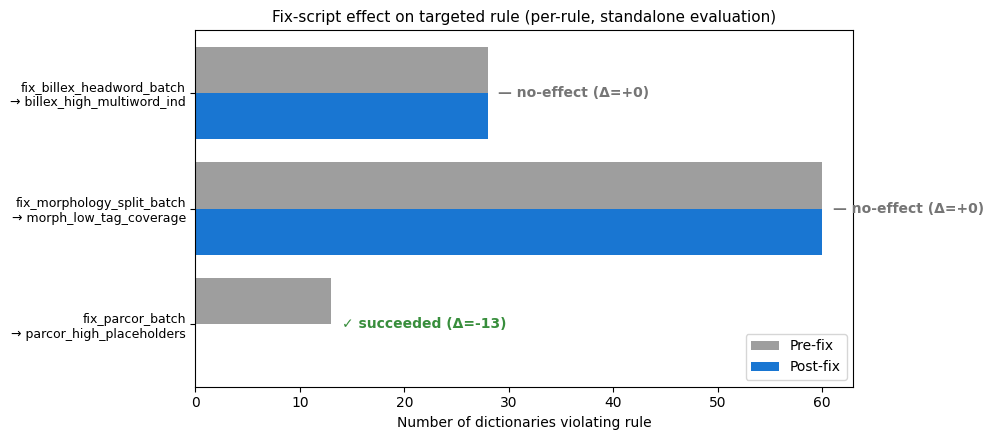

In [31]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y_pos = range(len(fix_eval_df))
width = 0.4

bars_pre  = ax.barh([y - width/2 for y in y_pos], fix_eval_df["violations_pre"],
                    height=width, color="#9e9e9e", label="Pre-fix")
bars_post = ax.barh([y + width/2 for y in y_pos], fix_eval_df["violations_post"],
                    height=width, color="#1976d2", label="Post-fix")

# Annotate with verdict
verdict_marker = {"succeeded": "✓", "no-effect": "—", "regressed": "✗"}
verdict_color  = {"succeeded": "#388e3c", "no-effect": "#757575", "regressed": "#d32f2f"}
for i, (_, row) in enumerate(fix_eval_df.iterrows()):
    marker = verdict_marker[row["verdict"]]
    color  = verdict_color[row["verdict"]]
    max_x  = max(row["violations_pre"], row["violations_post"])
    ax.text(max_x + 1, i, f"{marker} {row['verdict']} (Δ={row['delta']:+d})",
            va="center", fontsize=10, color=color, fontweight="bold")

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{row['fix_script']}\n→ {row['targeted_rule']}"
                    for _, row in fix_eval_df.iterrows()], fontsize=9)
ax.set_xlabel("Number of dictionaries violating rule")
ax.set_title("Fix-script effect on targeted rule (per-rule, standalone evaluation)",
             fontsize=11)
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DST_DIR / "_fix_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

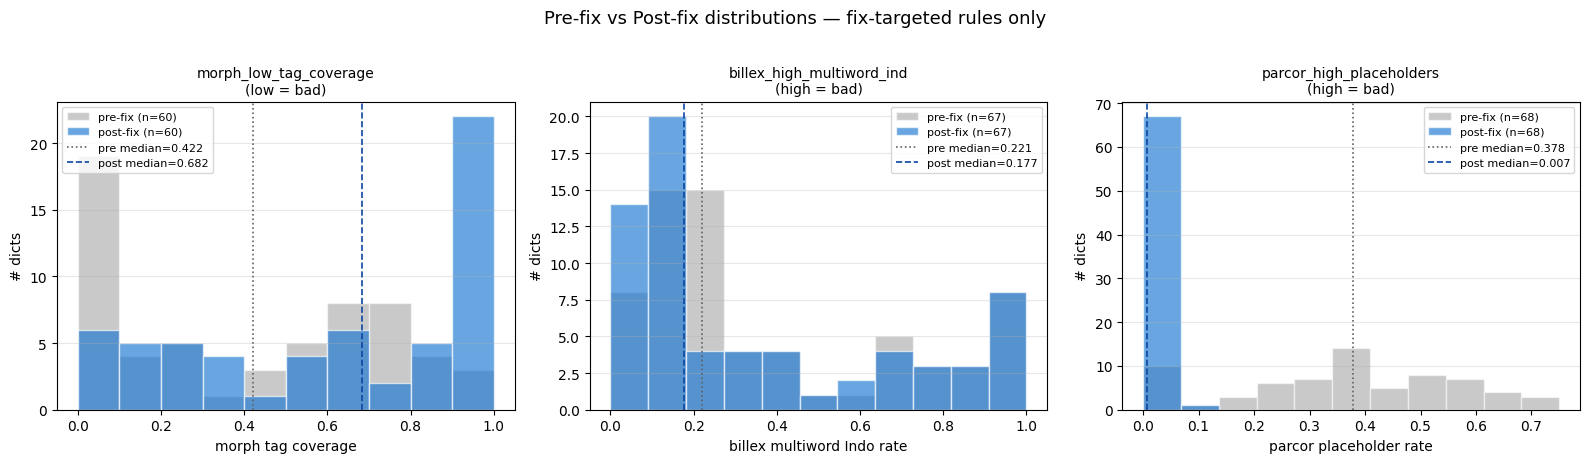


=== Pre-fix vs Post-fix percentile summary ===

Rule                           phase       min      p25      p50      p75      p90      max     mean
----------------------------------------------------------------------------------------------------
morph_low_tag_coverage         pre       0.000    0.000    0.422    0.691    0.821    0.981    0.395
morph_low_tag_coverage         post      0.000    0.274    0.682    0.939    0.980    1.000    0.608

billex_high_multiword_ind      pre       0.000    0.140    0.221    0.667    0.921    1.000    0.386
billex_high_multiword_ind      post      0.000    0.098    0.177    0.667    0.921    1.000    0.361

parcor_high_placeholders       pre       0.001    0.232    0.378    0.514    0.613    0.750    0.360
parcor_high_placeholders       post      0.000    0.003    0.007    0.011    0.019    0.083    0.010



In [32]:
# === Post-fix distributions for fix-targeted rules ===
# Compares pre-fix vs post-fix distributions for the 3 rules each fix script targets.
# Non-targeted rules are skipped because their values don't change after the fixes run.

# Map each targeted rule to (pre_metric_col, post_metric_col, direction, label)
TARGETED_RULES = [
    ("morph_low_tag_coverage",     "morph_tag_coverage",         "morph_fixed_tag_coverage",         "low",  "morph tag coverage"),
    ("billex_high_multiword_ind",  "billex_multiword_ind_rate",  "billex_fixed_multiword_ind_rate",  "high", "billex multiword Indo rate"),
    ("parcor_high_placeholders",   "parcor_placeholder_rate",    "parcor_fixed_placeholder_rate",    "high", "parcor placeholder rate"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (rule, pre_col, post_col, direction, label) in zip(axes, TARGETED_RULES):
    if pre_col not in metrics_df.columns or post_col not in metrics_df.columns:
        ax.text(0.5, 0.5, f"(missing column for {rule})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(rule, fontsize=10)
        continue

    pre_vals  = metrics_df[pre_col].dropna().values
    post_vals = metrics_df[post_col].dropna().values

    # Shared bin edges for fair pre/post comparison
    all_vals = np.concatenate([pre_vals, post_vals])
    n_bins = min(25, max(10, int(np.sqrt(len(all_vals)))))
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), n_bins + 1)

    ax.hist(pre_vals,  bins=bin_edges, alpha=0.55, color="#9e9e9e", edgecolor="white", label=f"pre-fix (n={len(pre_vals)})")
    ax.hist(post_vals, bins=bin_edges, alpha=0.65, color="#1976d2", edgecolor="white", label=f"post-fix (n={len(post_vals)})")

    # Overlay medians as vertical lines
    ax.axvline(np.median(pre_vals),  color="#616161", linestyle=":",  linewidth=1.2, label=f"pre median={np.median(pre_vals):.3f}")
    ax.axvline(np.median(post_vals), color="#0d47a1", linestyle="--", linewidth=1.2, label=f"post median={np.median(post_vals):.3f}")

    direction_phrase = "low = bad" if direction == "low" else "high = bad"
    ax.set_title(f"{rule}\n({direction_phrase})", fontsize=10)
    ax.set_xlabel(label)
    ax.set_ylabel("# dicts")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("Pre-fix vs Post-fix distributions — fix-targeted rules only", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_postfix_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

# === Percentile summary for each pre/post pair ===
print("\n=== Pre-fix vs Post-fix percentile summary ===\n")
print(f"{'Rule':<30} {'phase':<6} {'min':>8} {'p25':>8} {'p50':>8} {'p75':>8} {'p90':>8} {'max':>8} {'mean':>8}")
print("-" * 100)
for rule, pre_col, post_col, direction, _ in TARGETED_RULES:
    if pre_col not in metrics_df.columns or post_col not in metrics_df.columns:
        continue
    for phase, col in [("pre", pre_col), ("post", post_col)]:
        v = metrics_df[col].dropna().values
        if len(v) == 0:
            continue
        p25, p50, p75, p90 = np.percentile(v, [25, 50, 75, 90])
        print(f"{rule:<30} {phase:<6} {v.min():>8.3f} {p25:>8.3f} {p50:>8.3f} {p75:>8.3f} {p90:>8.3f} {v.max():>8.3f} {v.mean():>8.3f}")
    print()

## 9. NARRATIVE 2 — Structural Quality Tiers

This narrative is **standalone** from fix evaluation. It computes per-resource
tiers using the proportional 60% rule and aggregates to overall tiers.

§9.1: per-resource tier counts (post-fix)
§9.2: per-resource tier transitions (pre vs post)
§9.3: combined breakdown — how many dicts broken on N resources
§9.4: overall tier breakdown

### 9.1 Per-resource tier counts

In [33]:
tier_order = ["good", "needs_attention", "broken", "not_applicable"]

per_resource_counts = {}
for resource in ["billex", "morph", "parcor"]:
    pre  = metrics_df[f"{resource}_tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
    post = metrics_df[f"{resource}_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
    per_resource_counts[resource] = pd.DataFrame({
        "pre":  pre,
        "post": post,
        "delta": post - pre,
    })

print("=== Per-resource tier counts (pre vs post) ===")
for resource, df in per_resource_counts.items():
    print(f"\n--- {resource.upper()} ---")
    print(df)

=== Per-resource tier counts (pre vs post) ===

--- BILLEX ---
                 pre  post  delta
good              38    38      0
needs_attention   26    26      0
broken             4     4      0
not_applicable     0     0      0

--- MORPH ---
                 pre  post  delta
good               0     0      0
needs_attention   68    68      0
broken             0     0      0
not_applicable     0     0      0

--- PARCOR ---
                 pre  post  delta
good              29    38      9
needs_attention   35    27     -8
broken             4     3     -1
not_applicable     0     0      0


### 9.2 Per-resource tier transitions

In [34]:
transitions_data = {}
for resource in ["billex", "morph", "parcor"]:
    pre_col  = f"{resource}_tier_prefix"
    post_col = f"{resource}_tier_postfix"
    transitions = pd.crosstab(
        metrics_df[pre_col], metrics_df[post_col], margins=True
    ).reindex(
        index=tier_order + ["All"], columns=tier_order + ["All"], fill_value=0
    )
    transitions_data[resource] = transitions
    print(f"\n=== {resource.upper()} tier transitions (rows=pre, cols=post) ===")
    print(transitions)

# Save the long-format transition data
trans_long = []
for resource, trans in transitions_data.items():
    for pre_tier in tier_order:
        for post_tier in tier_order:
            trans_long.append({
                "resource":  resource,
                "pre_tier":  pre_tier,
                "post_tier": post_tier,
                "count":     int(trans.loc[pre_tier, post_tier]),
            })
trans_long_df = pd.DataFrame(trans_long)
trans_long_df.to_csv(DST_DIR / "_per_resource_transitions.csv", index=False)


=== BILLEX tier transitions (rows=pre, cols=post) ===
billex_tier_postfix  good  needs_attention  broken  not_applicable  All
billex_tier_prefix                                                     
good                   38                0       0               0   38
needs_attention         0               26       0               0   26
broken                  0                0       4               0    4
not_applicable          0                0       0               0    0
All                    38               26       4               0   68

=== MORPH tier transitions (rows=pre, cols=post) ===
morph_tier_postfix  good  needs_attention  broken  not_applicable  All
morph_tier_prefix                                                     
good                   0                0       0               0    0
needs_attention        0               68       0               0   68
broken                 0                0       0               0    0
not_applicable         0        

### 9.3 Broken-on-N-resources breakdown

In [35]:
n_broken = (
    (metrics_df["billex_tier_postfix"] == "broken").astype(int)
    + (metrics_df["morph_tier_postfix"] == "broken").astype(int)
    + (metrics_df["parcor_tier_postfix"] == "broken").astype(int)
)
metrics_df["n_resources_broken_postfix"] = n_broken

breakdown = pd.DataFrame({
    "n_resources_broken": [0, 1, 2, 3],
    "count": [int((n_broken == k).sum()) for k in [0, 1, 2, 3]],
})
breakdown["interpretation"] = [
    "no resources broken (good or needs_attention only)",
    "exactly 1 resource broken",
    "2 of 3 resources broken",
    "all 3 resources broken (catastrophically broken)",
]

print("=== Dicts broken on N resources (post-fix) ===")
print(breakdown.to_string(index=False))

# List the catastrophic cases (all 3 broken)
all_three_broken = metrics_df[n_broken == 3]
if len(all_three_broken) > 0:
    print(f"\nDicts with all 3 resources broken: "
          f"{', '.join(all_three_broken['dict_id'].astype(str).tolist())}")

=== Dicts broken on N resources (post-fix) ===
 n_resources_broken  count                                     interpretation
                  0     61 no resources broken (good or needs_attention only)
                  1      7                          exactly 1 resource broken
                  2      0                            2 of 3 resources broken
                  3      0   all 3 resources broken (catastrophically broken)


### 9.4 Overall tier breakdown

In [36]:
overall_pre  = metrics_df["overall_tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
overall_post = metrics_df["overall_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
overall_table = pd.DataFrame({
    "pre":   overall_pre,
    "post":  overall_post,
    "delta": overall_post - overall_pre,
})

print("=== Overall tier breakdown ===")
print(overall_table)

# Tier transitions for overall
overall_transitions = pd.crosstab(
    metrics_df["overall_tier_prefix"],
    metrics_df["overall_tier_postfix"],
    margins=True,
).reindex(index=tier_order + ["All"], columns=tier_order + ["All"], fill_value=0)

print("\n=== Overall tier transitions ===")
print(overall_transitions)

=== Overall tier breakdown ===
                 pre  post  delta
good               0     0      0
needs_attention   60    61      1
broken             8     7     -1
not_applicable     0     0      0

=== Overall tier transitions ===
overall_tier_postfix  good  needs_attention  broken  not_applicable  All
overall_tier_prefix                                                     
good                     0                0       0               0    0
needs_attention          0               60       0               0   60
broken                   0                1       7               0    8
not_applicable           0                0       0               0    0
All                      0               61       7               0   68


### 9.5 Per-dict tier export

In [37]:
tier_cols = [
    "dict_id",
    "billex_tier_prefix", "morph_tier_prefix", "parcor_tier_prefix", "overall_tier_prefix",
    "billex_tier_postfix", "morph_tier_postfix", "parcor_tier_postfix", "overall_tier_postfix",
    "billex_violations_prefix", "morph_violations_prefix", "parcor_violations_prefix",
    "billex_violations_postfix", "morph_violations_postfix", "parcor_violations_postfix",
    "n_resources_broken_postfix",
    "parcor_has_examples_in_source",
]
available = [c for c in tier_cols if c in metrics_df.columns]
metrics_df[available].to_csv(DST_DIR / "_quality_tiers.csv", index=False)
print(f"Wrote tier table: {DST_DIR / '_quality_tiers.csv'}")

Wrote tier table: ..\csvAnalysis\sanity_v3\_quality_tiers.csv


## 10. Catastrophic failures (extraction-stage)

In [38]:
CATASTROPHIC_ROW_THRESHOLD = 2

catastrophic = []
for _, row in metrics_df.iterrows():
    dict_id = row["dict_id"]
    prep = int(row.get("prep_rows", 0) or 0)

    if pd.notna(row.get("billex_rows")) and row["billex_rows"] <= CATASTROPHIC_ROW_THRESHOLD and prep > 100:
        catastrophic.append({
            "dict_id": dict_id, "resource": "billex",
            "rows": int(row["billex_rows"]), "prep_rows": prep,
            "suspected_cause": "Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.",
        })
    if pd.notna(row.get("morph_rows")) and row["morph_rows"] <= CATASTROPHIC_ROW_THRESHOLD and prep > 100:
        catastrophic.append({
            "dict_id": dict_id, "resource": "morph",
            "rows": int(row["morph_rows"]), "prep_rows": prep,
            "suspected_cause": "Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.",
        })
    if (pd.notna(row.get("parcor_rows")) and row["parcor_rows"] <= CATASTROPHIC_ROW_THRESHOLD
        and row.get("parcor_has_examples_in_source", False)):
        catastrophic.append({
            "dict_id": dict_id, "resource": "parcor",
            "rows": int(row["parcor_rows"]),
            "prep_rows": prep,
            "suspected_cause": "Source has example sentences but Parcor is empty — extraction-stage failure in notebook 11.",
        })

cat_df = pd.DataFrame(catastrophic)
cat_df.to_csv(DST_DIR / "_catastrophic_failures.csv", index=False)
if len(cat_df) == 0:
    print("No catastrophic failures detected.")
else:
    print(f"=== {len(cat_df)} catastrophic failures detected ===")
    print(cat_df.head(10).to_string(index=False))

=== 21 catastrophic failures detected ===
dict_id resource  rows  prep_rows                                                                                   suspected_cause
      3    morph     1        833      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     20   billex     0       2109 Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.
     20    morph     0       2109      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     22    morph     0        365      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     29   billex     1       1979 Extraction-stage failure in notebook 9 (Bilingual Lexicon). Prep has content but Billex is empty.
     29    morph     2       1979      Morphology extraction produced nothing. Source may have no derivations, OR extractor failed.
     31   billex     1       1371 

## 11. Source profiles

In [39]:
src_profiles = metrics_df[[
    "dict_id", "direction", "prep_rows",
    "parcor_has_examples_in_source", "parcor_source_example_rate",
]].copy()
src_profiles.to_csv(DST_DIR / "_source_profiles.csv", index=False)
print(f"Wrote source profiles: {len(src_profiles)} dicts")
print(f"  parcor applicable:    {src_profiles['parcor_has_examples_in_source'].sum()}")
print(f"  parcor not_applicable:{(~src_profiles['parcor_has_examples_in_source']).sum()}")

Wrote source profiles: 68 dicts
  parcor applicable:    68
  parcor not_applicable:0


## 12. Visualisations

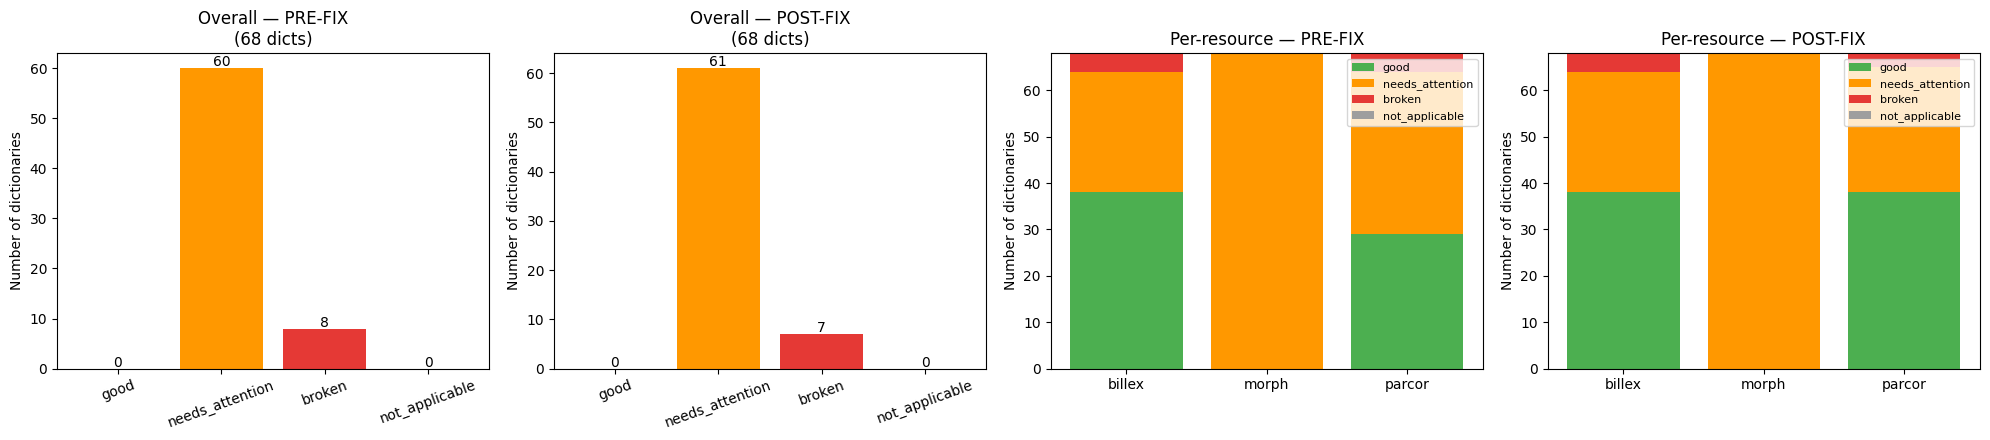

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800",
               "broken": "#e53935", "not_applicable": "#9e9e9e"}

# Panel 1 — Overall pre
overall_pre_counts = metrics_df["overall_tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
axes[0].bar(overall_pre_counts.index, overall_pre_counts.values,
            color=[tier_colors[t] for t in overall_pre_counts.index])
for i, v in enumerate(overall_pre_counts.values):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontsize=10)
axes[0].set_title(f"Overall — PRE-FIX\n({len(metrics_df)} dicts)")
axes[0].set_ylabel("Number of dictionaries")
axes[0].tick_params(axis="x", rotation=20)

# Panel 2 — Overall post
overall_post_counts = metrics_df["overall_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
axes[1].bar(overall_post_counts.index, overall_post_counts.values,
            color=[tier_colors[t] for t in overall_post_counts.index])
for i, v in enumerate(overall_post_counts.values):
    axes[1].text(i, v + 0.4, str(v), ha="center", fontsize=10)
axes[1].set_title(f"Overall — POST-FIX\n({len(metrics_df)} dicts)")
axes[1].set_ylabel("Number of dictionaries")
axes[1].tick_params(axis="x", rotation=20)

# Panel 3 — Per-resource pre
resources = ["billex", "morph", "parcor"]
pre_per_res = pd.DataFrame({
    r: metrics_df[f"{r}_tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
    for r in resources
}).T
bottom = np.zeros(len(resources))
for tier in tier_order:
    axes[2].bar(pre_per_res.index, pre_per_res[tier].values, bottom=bottom,
                color=tier_colors[tier], label=tier)
    bottom += pre_per_res[tier].values
axes[2].set_title("Per-resource — PRE-FIX")
axes[2].set_ylabel("Number of dictionaries")
axes[2].legend(fontsize=8, loc="upper right")

# Panel 4 — Per-resource post
post_per_res = pd.DataFrame({
    r: metrics_df[f"{r}_tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
    for r in resources
}).T
bottom = np.zeros(len(resources))
for tier in tier_order:
    axes[3].bar(post_per_res.index, post_per_res[tier].values, bottom=bottom,
                color=tier_colors[tier], label=tier)
    bottom += post_per_res[tier].values
axes[3].set_title("Per-resource — POST-FIX")
axes[3].set_ylabel("Number of dictionaries")
axes[3].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(DST_DIR / "_tier_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

### 12.2 Per-resource tier transitions visualization

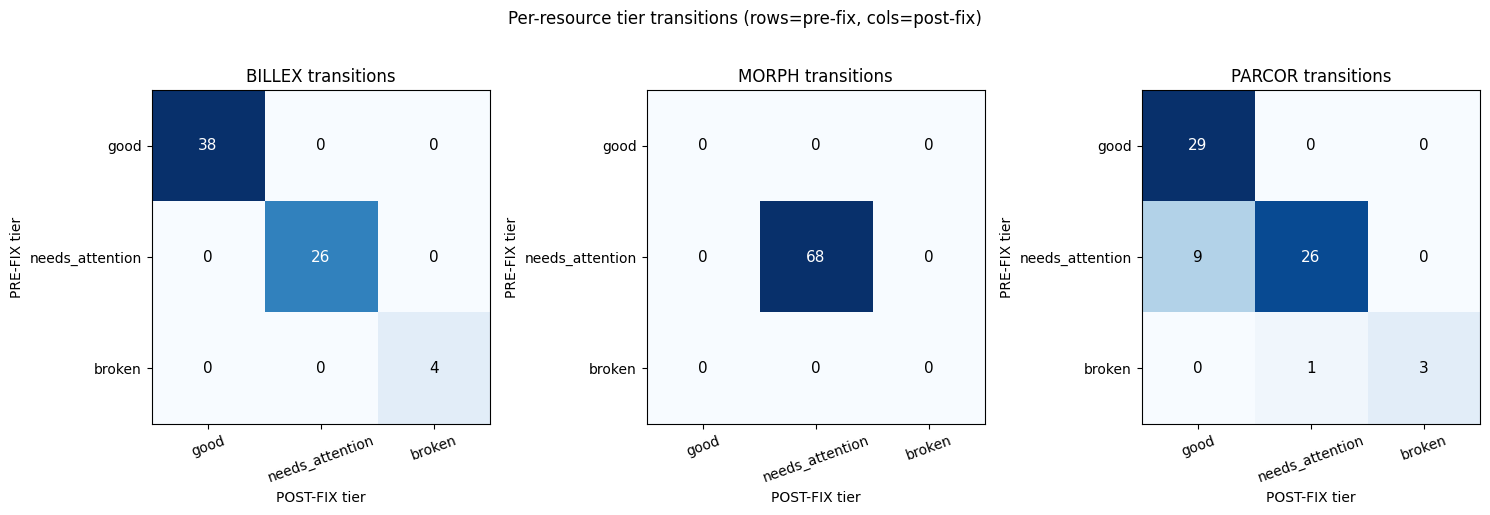

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tier_order_no_na = ["good", "needs_attention", "broken"]

for ax, resource in zip(axes, resources):
    trans = transitions_data[resource].drop("All", errors="ignore", axis=0).drop("All", errors="ignore", axis=1)
    trans = trans.reindex(index=tier_order_no_na, columns=tier_order_no_na, fill_value=0)

    im = ax.imshow(trans.values, cmap="Blues", aspect="auto", vmin=0)
    ax.set_xticks(range(len(tier_order_no_na)))
    ax.set_xticklabels(tier_order_no_na, rotation=20)
    ax.set_yticks(range(len(tier_order_no_na)))
    ax.set_yticklabels(tier_order_no_na)
    ax.set_xlabel("POST-FIX tier")
    ax.set_ylabel("PRE-FIX tier")
    ax.set_title(f"{resource.upper()} transitions")

    # Annotate cells
    for i in range(len(tier_order_no_na)):
        for j in range(len(tier_order_no_na)):
            value = int(trans.values[i, j])
            color = "white" if value > trans.values.max() * 0.5 else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=11)

plt.suptitle("Per-resource tier transitions (rows=pre-fix, cols=post-fix)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_tier_transitions.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Aggregate summary

In [42]:
aggregate = {
    "total_dictionaries_audited":    len(metrics_df),
    "broken_proportion_threshold":   BROKEN_PROPORTION_THRESHOLD,
    # Overall
    "overall_prefix_good":            int((metrics_df["overall_tier_prefix"] == "good").sum()),
    "overall_prefix_needs_attention": int((metrics_df["overall_tier_prefix"] == "needs_attention").sum()),
    "overall_prefix_broken":          int((metrics_df["overall_tier_prefix"] == "broken").sum()),
    "overall_postfix_good":            int((metrics_df["overall_tier_postfix"] == "good").sum()),
    "overall_postfix_needs_attention": int((metrics_df["overall_tier_postfix"] == "needs_attention").sum()),
    "overall_postfix_broken":          int((metrics_df["overall_tier_postfix"] == "broken").sum()),
    # Per-resource broken counts (postfix)
    "billex_postfix_broken": int((metrics_df["billex_tier_postfix"] == "broken").sum()),
    "morph_postfix_broken":  int((metrics_df["morph_tier_postfix"] == "broken").sum()),
    "parcor_postfix_broken": int((metrics_df["parcor_tier_postfix"] == "broken").sum()),
    # Catastrophic counts
    "n_dicts_3_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 3).sum()),
    "n_dicts_2_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 2).sum()),
    "n_dicts_1_resource_broken":  int((metrics_df["n_resources_broken_postfix"] == 1).sum()),
    "n_dicts_0_resources_broken": int((metrics_df["n_resources_broken_postfix"] == 0).sum()),
    # Tier movement
    "dicts_overall_improved":  int((metrics_df["overall_tier_prefix"] != metrics_df["overall_tier_postfix"]).sum()),
    "catastrophic_failures":   int(len(cat_df)),
    # Fix evaluation
    "fixes_succeeded": int((fix_eval_df["verdict"] == "succeeded").sum()),
    "fixes_no_effect": int((fix_eval_df["verdict"] == "no-effect").sum()),
    "fixes_regressed": int((fix_eval_df["verdict"] == "regressed").sum()),
}

agg_df = pd.DataFrame([aggregate]).T.rename(columns={0: "value"})
agg_df.to_csv(DST_DIR / "_aggregate_stats.csv")
for k, v in aggregate.items():
    print(f"  {k:<38} {v}")
print(f"\nAll outputs in: {DST_DIR.resolve()}")

  total_dictionaries_audited             68
  broken_proportion_threshold            0.6
  overall_prefix_good                    0
  overall_prefix_needs_attention         60
  overall_prefix_broken                  8
  overall_postfix_good                   0
  overall_postfix_needs_attention        61
  overall_postfix_broken                 7
  billex_postfix_broken                  4
  morph_postfix_broken                   0
  parcor_postfix_broken                  3
  n_dicts_3_resources_broken             0
  n_dicts_2_resources_broken             0
  n_dicts_1_resource_broken              7
  n_dicts_0_resources_broken             61
  dicts_overall_improved                 1
  catastrophic_failures                  21
  fixes_succeeded                        1
  fixes_no_effect                        2
  fixes_regressed                        0

All outputs in: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\sanity_v3


## 14. Drill-down (optional, for inspection)

In [43]:
DRILL_DOWN_DICT_ID = "4"

target = metrics_df[metrics_df["dict_id"] == DRILL_DOWN_DICT_ID]
if len(target) == 0:
    print(f"Dictionary {DRILL_DOWN_DICT_ID} not found.")
else:
    row = target.iloc[0]
    print(f"=== Dict {DRILL_DOWN_DICT_ID} — drill-down ===\n")
    print(f"Direction: {row['direction']} (known: {row['direction_known']})")
    print(f"Prep rows: {row['prep_rows']}")
    print(f"Source has examples (parcor): {row['parcor_has_examples_in_source']}")
    print()
    for resource in ["billex", "morph", "parcor"]:
        n_rules = len(RESOURCE_RULES[resource])
        print(f"--- {resource.upper()} ({n_rules} rules) ---")
        print(f"  tier (pre):   {row[f'{resource}_tier_prefix']}  "
              f"({row[f'{resource}_violation_count_prefix']}/{n_rules} rules violated)")
        print(f"  tier (post):  {row[f'{resource}_tier_postfix']}  "
              f"({row[f'{resource}_violation_count_postfix']}/{n_rules} rules violated)")
        print(f"  violations (pre):  {row[f'{resource}_violations_prefix'] or '(none)'}")
        print(f"  violations (post): {row[f'{resource}_violations_postfix'] or '(none)'}")
        print()
    print(f"OVERALL: {row['overall_tier_prefix']}  →  {row['overall_tier_postfix']}")
    print(f"\nResources broken (post-fix): {row['n_resources_broken_postfix']} of 3")

=== Dict 4 — drill-down ===

Direction: 1 (known: True)
Prep rows: 3212
Source has examples (parcor): True

--- BILLEX (3 rules) ---
  tier (pre):   good  (0/3 rules violated)
  tier (post):  good  (0/3 rules violated)
  violations (pre):  (none)
  violations (post): (none)

--- MORPH (2 rules) ---
  tier (pre):   needs_attention  (1/2 rules violated)
  tier (post):  needs_attention  (1/2 rules violated)
  violations (pre):  morph_low_tag_coverage
  violations (post): morph_low_tag_coverage

--- PARCOR (4 rules) ---
  tier (pre):   needs_attention  (1/4 rules violated)
  tier (post):  good  (0/4 rules violated)
  violations (pre):  parcor_high_placeholders
  violations (post): (none)

OVERALL: needs_attention  →  needs_attention

Resources broken (post-fix): 0 of 3
